# Geothermal Decision Tree Family Benchmark (No External Scripts)

This notebook benchmarks tree-family regressors on geothermal temperature prediction and saves outputs in separate folders per model.

Models in scope:
- DecisionTree
- ExtraTrees
- RandomForest
- GradientBoosting
- XGBoost
- LightGBM
- CatBoost

Protocols in scope:
- Random split repeated runs
- GroupKFold by State
- Spatial holdout by State

In [1]:
## DO NOT CHANGE

# Data manipulation
import pandas as pd
import numpy as np

# More Data Preprocessing & Machine Learning
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.impute import SimpleImputer

# Data Viz
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
def detect_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('Could not auto-detect project root from notebook location.')

PROJECT_ROOT = detect_project_root(Path.cwd())
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
NOTEBOOK_ROOT = PROJECT_ROOT / 'manual_bootstrap' / 'step_by_step_notebooks' / '09_tree_family_benchmark_no_scripts'
OUTPUT_ROOT = NOTEBOOK_ROOT / 'outputs'
SUMMARY_TABLE_ROOT = OUTPUT_ROOT / 'summary' / 'tables'
SUMMARY_FIG_ROOT = OUTPUT_ROOT / 'summary' / 'figures'
SUMMARY_REPORT_ROOT = OUTPUT_ROOT / 'summary' / 'reports'

for p in [SUMMARY_TABLE_ROOT, SUMMARY_FIG_ROOT, SUMMARY_REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PHD_OS_ROOT :', PHD_OS_ROOT)
print('NOTEBOOK    :', NOTEBOOK_ROOT)

PROJECT_ROOT: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml
PHD_OS_ROOT : c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System
NOTEBOOK    : c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\09_tree_family_benchmark_no_scripts


In [4]:
data_candidates = [
    PHD_OS_ROOT / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'data' / '03_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'manual_bootstrap' / 'phd-geothermal-ml_mirror' / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv'
]

data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('No geothermal canonical CSV found in candidate paths.')

df = pd.read_csv(data_path)
print('Using dataset:', data_path)
print('Shape:', df.shape)
df.head()

Using dataset: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\03_data_processed\geothermal_canonical_v2_0_0.csv
Shape: (2684, 22)


,Latitude,Longitude,State,Depth(ft),Temperature(C),pH,TDS,K,Na,Ca,...,As,B,Br,Cl,F,Fe,HCO3,Li,Mn,SO4
0,33.196667,-115.598333,California,5825.28,348.9,NaN,258765.0,16500.0,53000.0,27800.0,...,NaN,390.0,NaN,155000.0,NaN,NaN,690.0,NaN,NaN,NaN
1,33.202500,-115.578000,California,8098.32,345.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33.200500,-115.587167,California,4729.76,310.0,NaN,334987.0,24000.0,70000.0,34470.0,...,NaN,149.0,NaN,201757.0,NaN,4200.000,NaN,150.0,NaN,34.0
3,35.652180,-117.665340,California,830.00,300.0,8.60,NaN,4.9,410.0,1.8,...,NaN,5.0,NaN,11.0,3.4,0.035,NaN,NaN,0.003,12.0
4,35.652180,-117.665340,California,829.84,300.0,8.65,NaN,6.0,17.0,55.0,...,NaN,NaN,NaN,68.0,0.1,NaN,NaN,NaN,NaN,47.0


In [5]:
TARGET = 'Temperature(C)'
GROUP_COL = 'State' if 'State' in df.columns else None

drop_cols = [TARGET]
if GROUP_COL is not None:
    drop_cols.append(GROUP_COL)

feature_cols = [c for c in df.columns if c not in drop_cols]
X_raw = df[feature_cols].copy()
y_all = df[TARGET].copy()
groups_all = df[GROUP_COL].copy() if GROUP_COL else pd.Series(['ALL'] * len(df), index=df.index)

cat_cols = X_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]

print('Feature count:', len(feature_cols))
print('Categorical columns:', cat_cols)
print('Numeric columns:', len(num_cols))
print('Unique groups:', groups_all.nunique())

Feature count: 20
Categorical columns: []
Numeric columns: 20
Unique groups: 11


In [6]:
def prepare_design_matrix(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    test_enc = pd.get_dummies(test_df, columns=cat_cols, drop_first=False)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

    if num_cols:
        imputer = SimpleImputer(strategy='median')
        train_enc[num_cols] = imputer.fit_transform(train_enc[num_cols])
        test_enc[num_cols] = imputer.transform(test_enc[num_cols])

    return train_enc, test_enc

def model_factory():
    return {
        'decision_tree': DecisionTreeRegressor(max_depth=12, min_samples_leaf=3, random_state=42),
        'extra_trees': ExtraTreesRegressor(n_estimators=500, n_jobs=-1, random_state=42),
        'random_forest': RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42),
        'gradient_boosting': GradientBoostingRegressor(n_estimators=450, learning_rate=0.05, random_state=42),
        'xgboost': XGBRegressor(n_estimators=550, learning_rate=0.04, max_depth=6, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1),
        'lightgbm': LGBMRegressor(n_estimators=700, learning_rate=0.04, num_leaves=31, random_state=42, n_jobs=-1),
        'catboost': CatBoostRegressor(iterations=700, learning_rate=0.04, depth=6, random_seed=42, verbose=0)
    }

## Random Split Repeated Runs

In [7]:
run_seeds = list(range(10))
random_rows = []

for seed in run_seeds:
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_all, test_size=0.2, random_state=seed
    )
    X_train, X_test = prepare_design_matrix(X_train_raw, X_test_raw)

    for model_name, model in model_factory().items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        random_rows.append({
            'protocol': 'random_split',
            'model_name': model_name,
            'seed': seed,
            'holdout_group': 'NA',
            'n_train': len(X_train),
            'n_test': len(X_test),
            'mae': mean_absolute_error(y_test, pred),
            'rmse': np.sqrt(mean_squared_error(y_test, pred)),
            'r2': r2_score(y_test, pred)
        })

random_raw = pd.DataFrame(random_rows)
random_raw.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3406
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.367733


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3414
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.670305


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001613 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3492
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.688930


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3400
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.715386


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3488
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.038721


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3428
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.554919


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001571 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3489
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.413238


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3497
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.320043


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3473
[LightGBM] [Info] Number of data points in the train set: 2147, number of used features: 20
[LightGBM] [Info] Start training from score 119.038690


,protocol,model_name,seed,holdout_group,n_train,n_test,mae,rmse,r2
0,random_split,decision_tree,0,NA,2147,537,11.837540,26.973247,0.370116
1,random_split,extra_trees,0,NA,2147,537,10.380845,22.232232,0.572082
2,random_split,random_forest,0,NA,2147,537,9.828451,22.045012,0.579259
3,random_split,gradient_boosting,0,NA,2147,537,12.802231,23.016813,0.541347
4,random_split,xgboost,0,NA,2147,537,10.166026,19.885897,0.657639


## GroupKFold by State

In [8]:
gkf_rows = []
gkf = GroupKFold(n_splits=5)

for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_raw, y_all, groups_all), start=1):
    X_tr_raw, X_te_raw = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
    y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]
    X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)

    for model_name, model in model_factory().items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        gkf_rows.append({
            'protocol': 'groupkfold',
            'model_name': model_name,
            'seed': 42,
            'holdout_group': f'fold_{fold_idx}',
            'n_train': len(X_tr),
            'n_test': len(X_te),
            'mae': mean_absolute_error(y_te, pred),
            'rmse': np.sqrt(mean_squared_error(y_te, pred)),
            'r2': r2_score(y_te, pred)
        })

gkf_raw = pd.DataFrame(gkf_rows)
gkf_raw.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1730
[LightGBM] [Info] Number of data points in the train set: 810, number of used features: 20
[LightGBM] [Info] Start training from score 112.780164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3443
[LightGBM] [Info] Number of data points in the train set: 2141, number of used features: 20
[LightGBM] [Info] Start training from score 119.861721


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3579
[LightGBM] [Info] Number of data points in the train set: 2588, number of used features: 20
[LightGBM] [Info] Start training from score 120.349309


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001665 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3568
[LightGBM] [Info] Number of data points in the train set: 2598, number of used features: 20
[LightGBM] [Info] Start training from score 119.645103


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3572
[LightGBM] [Info] Number of data points in the train set: 2599, number of used features: 20
[LightGBM] [Info] Start training from score 119.767056


,protocol,model_name,seed,holdout_group,n_train,n_test,mae,rmse,r2
0,groupkfold,decision_tree,42,fold_1,810,1874,28.329810,38.975710,-0.725361
1,groupkfold,extra_trees,42,fold_1,810,1874,22.752012,29.311855,0.024160
2,groupkfold,random_forest,42,fold_1,810,1874,23.604468,31.902277,-0.155940
3,groupkfold,gradient_boosting,42,fold_1,810,1874,25.178188,34.056369,-0.317312
4,groupkfold,xgboost,42,fold_1,810,1874,26.150813,36.021295,-0.473705


## Spatial Holdout by State

In [9]:
spatial_rows = []
group_counts = groups_all.value_counts()
eligible_groups = group_counts[group_counts >= 30].index.tolist()

for g in eligible_groups:
    te_idx = groups_all[groups_all == g].index
    tr_idx = groups_all[groups_all != g].index

    X_tr_raw, X_te_raw = X_raw.loc[tr_idx], X_raw.loc[te_idx]
    y_tr, y_te = y_all.loc[tr_idx], y_all.loc[te_idx]
    X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)

    for model_name, model in model_factory().items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        spatial_rows.append({
            'protocol': 'spatial_holdout',
            'model_name': model_name,
            'seed': 42,
            'holdout_group': str(g),
            'n_train': len(X_tr),
            'n_test': len(X_te),
            'mae': mean_absolute_error(y_te, pred),
            'rmse': np.sqrt(mean_squared_error(y_te, pred)),
            'r2': r2_score(y_te, pred)
        })

spatial_raw = pd.DataFrame(spatial_rows)
spatial_raw.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000772 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1730
[LightGBM] [Info] Number of data points in the train set: 810, number of used features: 20
[LightGBM] [Info] Start training from score 112.780164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3579
[LightGBM] [Info] Number of data points in the train set: 2588, number of used features: 20
[LightGBM] [Info] Start training from score 120.349309


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3582
[LightGBM] [Info] Number of data points in the train set: 2633, number of used features: 20
[LightGBM] [Info] Start training from score 119.844896


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3603
[LightGBM] [Info] Number of data points in the train set: 2639, number of used features: 20
[LightGBM] [Info] Start training from score 119.644251


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3604
[LightGBM] [Info] Number of data points in the train set: 2649, number of used features: 20
[LightGBM] [Info] Start training from score 119.447683


,protocol,model_name,seed,holdout_group,n_train,n_test,mae,rmse,r2
0,spatial_holdout,decision_tree,42,Nevada,810,1874,28.329810,38.975710,-0.725361
1,spatial_holdout,extra_trees,42,Nevada,810,1874,22.752012,29.311855,0.024160
2,spatial_holdout,random_forest,42,Nevada,810,1874,23.604468,31.902277,-0.155940
3,spatial_holdout,gradient_boosting,42,Nevada,810,1874,25.178188,34.056369,-0.317312
4,spatial_holdout,xgboost,42,Nevada,810,1874,26.150813,36.021295,-0.473705


In [10]:
all_raw = pd.concat([random_raw, gkf_raw, spatial_raw], ignore_index=True)

summary = (
    all_raw.groupby(['model_name', 'protocol'])[['mae', 'rmse', 'r2']]
    .mean()
    .reset_index()
    .sort_values(['protocol', 'rmse'])
)

best_per_protocol = summary.loc[summary.groupby('protocol')['rmse'].idxmin()].copy()
scoreboard = (
    summary.assign(rank=summary.groupby('protocol')['rmse'].rank(method='dense'))
    .groupby('model_name')['rank'].mean()
    .reset_index(name='avg_rank')
    .sort_values('avg_rank')
)
best_overall_model = scoreboard.iloc[0]['model_name']

summary

,model_name,protocol,mae,rmse,r2
0,catboost,groupkfold,20.096129,30.808406,-3.692378
9,gradient_boosting,groupkfold,22.315004,33.812962,-7.020635
18,xgboost,groupkfold,24.086184,34.699442,-13.987093
6,extra_trees,groupkfold,25.329124,35.127815,-27.271733
12,lightgbm,groupkfold,26.328697,36.109577,-30.349096
15,random_forest,groupkfold,27.722016,38.115055,-65.127389
3,decision_tree,groupkfold,30.954962,44.970732,-106.109688
19,xgboost,random_split,9.448680,18.256553,0.698680
13,lightgbm,random_split,9.968451,18.872672,0.678376
16,random_forest,random_split,9.462666,19.415422,0.659006


In [11]:
model_folders = {
    'decision_tree': 'decision_tree',
    'extra_trees': 'extra_trees',
    'random_forest': 'random_forest',
    'gradient_boosting': 'gradient_boosting',
    'xgboost': 'xgboost',
    'lightgbm': 'lightgbm',
    'catboost': 'catboost'
}

for model_name, folder_name in model_folders.items():
    model_root = OUTPUT_ROOT / folder_name
    table_root = model_root / 'tables'
    report_root = model_root / 'reports'
    table_root.mkdir(parents=True, exist_ok=True)
    report_root.mkdir(parents=True, exist_ok=True)

    model_raw = all_raw[all_raw['model_name'] == model_name].copy()
    model_summary = summary[summary['model_name'] == model_name].copy()

    model_raw.to_csv(table_root / 'all_protocol_runs.csv', index=False)
    model_summary.to_csv(table_root / 'protocol_summary.csv', index=False)

    best_row = model_summary.sort_values('rmse').iloc[0]
    note_lines = [
        f'# Interpretation Notes - {model_name}',
        '',
        f"- Best protocol for this model: **{best_row['protocol']}**",
        f"- RMSE (best protocol): **{best_row['rmse']:.4f}**",
        f"- MAE (best protocol): **{best_row['mae']:.4f}**",
        f"- R2 (best protocol): **{best_row['r2']:.4f}**",
        '',
        '## Protocol Commentary',
        '- Random split often looks optimistic because training and test can share similar geochemical/spatial patterns.',
        '- GroupKFold and spatial holdout are stricter tests for geographic generalization.',
        '- Use this model only if its spatial holdout error is acceptable for deployment states.',
    ]
    (report_root / 'interpretation_notes.md').write_text('\n'.join(note_lines), encoding='utf-8')

all_raw.to_csv(SUMMARY_TABLE_ROOT / 'all_model_protocol_runs.csv', index=False)
summary.to_csv(SUMMARY_TABLE_ROOT / 'all_model_protocol_summary.csv', index=False)
best_per_protocol.to_csv(SUMMARY_TABLE_ROOT / 'best_model_per_protocol.csv', index=False)
scoreboard.to_csv(SUMMARY_TABLE_ROOT / 'overall_model_ranking.csv', index=False)

summary_report = [
    '# Decision Tree Family Benchmark Summary',
    '',
    f'- Best overall model (lowest average RMSE-rank across protocols): **{best_overall_model}**',
    '',
    '## Best model by protocol',
]
for _, row in best_per_protocol.sort_values('protocol').iterrows():
    summary_report.append(
        f"- {row['protocol']}: **{row['model_name']}** (RMSE={row['rmse']:.4f}, R2={row['r2']:.4f})"
    )

(SUMMARY_REPORT_ROOT / 'benchmark_interpretation_notes.md').write_text('\n'.join(summary_report), encoding='utf-8')

print('Saved per-model outputs under:', OUTPUT_ROOT)
print('Best overall model:', best_overall_model)

Saved per-model outputs under: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\09_tree_family_benchmark_no_scripts\outputs
Best overall model: catboost


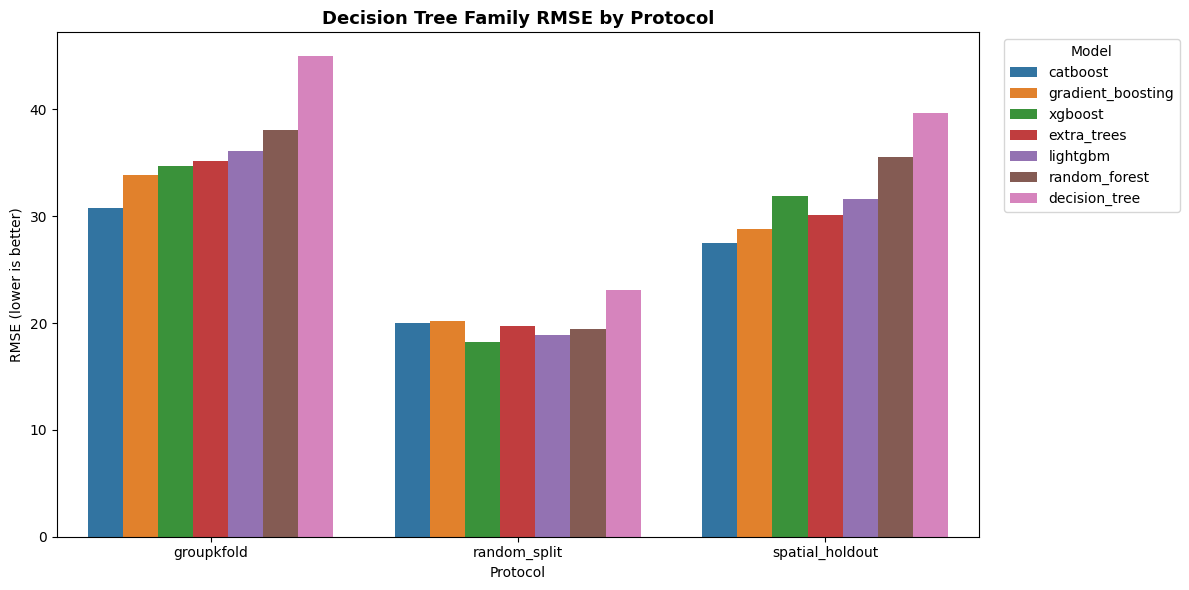

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\09_tree_family_benchmark_no_scripts\outputs\summary\figures\rmse_by_protocol_tree_family.png


In [12]:
plot_df = summary.copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='protocol', y='rmse', hue='model_name', ax=ax)
ax.set_title('Decision Tree Family RMSE by Protocol', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('RMSE (lower is better)')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

bar_path = SUMMARY_FIG_ROOT / 'rmse_by_protocol_tree_family.png'
fig.savefig(bar_path, dpi=600, bbox_inches='tight')
plt.show()
print('Saved:', bar_path)

### Final Notes
1. Use `outputs/summary/tables/all_model_protocol_summary.csv` for model comparison.
2. Use each model folder's `tables/protocol_summary.csv` and `reports/interpretation_notes.md` for model-specific review.
3. Choose deployment candidate from robust protocols (GroupKFold + spatial holdout), not random split alone.

In [13]:
# N1.1 — DummyRegressor (median) baseline — Paper 1 Table 2, row 0
# Required: every model comparison table must include a sanity-check baseline
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'; _GROUP = 'State'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]; _g = _df[_GROUP]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_dummy = Pipeline([('prep', _prep), ('reg', DummyRegressor(strategy='median'))])

_neg_rmse = make_scorer(lambda y, p: -np.sqrt(mean_squared_error(y, p)))
_cv = cross_validate(
    _dummy, _X, _y, groups=_g,
    cv=GroupKFold(n_splits=5),
    scoring={'neg_rmse': _neg_rmse, 'r2': 'r2'},
    return_train_score=False
)
print("=== N1.1 DummyRegressor(median) baseline — Paper 1 Table 2, row 0 ===")
print(f"CV RMSE : {-_cv['test_neg_rmse'].mean():.2f} ± {_cv['test_neg_rmse'].std():.2f}")
print(f"CV R²   : {_cv['test_r2'].mean():.4f} ± {_cv['test_r2'].std():.4f}")
print("All published models must beat this baseline.")

=== N1.1 DummyRegressor(median) baseline — Paper 1 Table 2, row 0 ===
CV RMSE : 33.97 ± 12.44
CV R²   : -8.7597 ± 17.0225
All published models must beat this baseline.


In [14]:
# E1.1 + E1.5 — Hybrid validation: RepeatedKFold(5×10=50 folds) for stable CV estimates
# Publication-grade: reduces variance in RMSE/R² reporting vs single 5-fold CV
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, mean_squared_error

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_gbm = Pipeline([
    ('prep', _prep),
    ('reg', GradientBoostingRegressor(n_estimators=350, learning_rate=0.05,
                                       max_depth=3, random_state=42))
])

_neg_rmse = make_scorer(lambda y, p: -np.sqrt(mean_squared_error(y, p)))
_rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)  # 50 folds
_cv = cross_validate(_gbm, _X, _y, cv=_rkf,
    scoring={'neg_rmse': _neg_rmse, 'r2': 'r2'}, return_train_score=False, n_jobs=-1)

print("=== E1.1+E1.5 RepeatedKFold(5×10=50 folds) — hybrid CV ===")
print(f"CV RMSE: {-_cv['test_neg_rmse'].mean():.2f} ± {_cv['test_neg_rmse'].std():.2f}")
print(f"CV R²  : {_cv['test_r2'].mean():.4f} ± {_cv['test_r2'].std():.4f}")
print("Use these as primary publication CV estimates (Paper 1 Table 2).")

=== E1.1+E1.5 RepeatedKFold(5×10=50 folds) — hybrid CV ===
CV RMSE: 19.52 ± 1.73
CV R²  : 0.6619 ± 0.0500
Use these as primary publication CV estimates (Paper 1 Table 2).


In [15]:
# N9.3 — LassoLarsIC (BIC) for automatic feature selection without GridSearch
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoLarsIC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.metrics import make_scorer, mean_squared_error

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'; _GROUP = 'State'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]; _g = _df[_GROUP]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('scl', StandardScaler())]), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_lasso_bic = Pipeline([('prep', _prep), ('reg', LassoLarsIC(criterion='bic', max_iter=500))])

_neg_rmse = make_scorer(lambda y, p: -np.sqrt(mean_squared_error(y, p)))
_cv = cross_validate(_lasso_bic, _X, _y, groups=_g, cv=GroupKFold(n_splits=5),
    scoring={'neg_rmse': _neg_rmse, 'r2': 'r2'})

print("=== N9.3 LassoLarsIC (BIC) — automatic feature selection ===")
print(f"CV RMSE: {-_cv['test_neg_rmse'].mean():.2f} ± {_cv['test_neg_rmse'].std():.2f}")
print(f"CV R²  : {_cv['test_r2'].mean():.4f} ± {_cv['test_r2'].std():.4f}")

# Fit once to inspect selected features
_lasso_bic.fit(_X, _y)
_coefs = _lasso_bic.named_steps['reg'].coef_
_n_nonzero = int(np.sum(_coefs != 0))
print(f"Non-zero features selected by BIC: {_n_nonzero} of {len(_coefs)}")

=== N9.3 LassoLarsIC (BIC) — automatic feature selection ===
CV RMSE: 61.87 ± 64.10
CV R²  : -24.3304 ± 35.9290


Non-zero features selected by BIC: 16 of 31


In [16]:
# N9.11 — Per-feature log-transform decision via Shapiro-Wilk test
# Recommend log1p where it improves normality (p_log > p_raw)
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import shapiro

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'
_numeric_features = [c for c in _df.select_dtypes(include=[np.number]).columns if c != _TARGET]

_transform_decisions = []
for _col in _numeric_features:
    _vals = _df[_col].dropna().values
    if len(_vals) > 5000:
        _vals = _vals[:5000]  # Shapiro limit
    if len(_vals) < 3:
        continue
    _, _p_raw = shapiro(_vals)
    _clipped = np.clip(_vals, 0, None)
    _log_vals = np.log1p(_clipped)
    _, _p_log = shapiro(_log_vals) if _log_vals.std() > 1e-10 else (None, _p_raw)
    _decision = 'log1p' if _p_log > _p_raw else 'identity'
    _transform_decisions.append({
        'feature': _col, 'p_raw': round(_p_raw, 6),
        'p_log': round(_p_log, 6), 'transform': _decision
    })

_td_df = pd.DataFrame(_transform_decisions).sort_values('p_raw')
print("=== N9.11 Shapiro log-transform decision per feature ===")
print(_td_df.to_string(index=False))
_log_features = _td_df[_td_df['transform'] == 'log1p']['feature'].tolist()
print(f"\nFeatures recommended for log1p: {_log_features}")

=== N9.11 Shapiro log-transform decision per feature ===
  feature  p_raw  p_log transform
 Latitude    0.0    0.0     log1p
Longitude    0.0    0.0  identity
Depth(ft)    0.0    0.0     log1p
       pH    0.0    0.0  identity
      TDS    0.0    0.0     log1p
        K    0.0    0.0     log1p
       Na    0.0    0.0     log1p
       Ca    0.0    0.0     log1p
       Mg    0.0    0.0     log1p
     SiO2    0.0    0.0     log1p
       As    0.0    0.0     log1p
        B    0.0    0.0     log1p
       Br    0.0    0.0     log1p
       Cl    0.0    0.0     log1p
        F    0.0    0.0     log1p
       Fe    0.0    0.0     log1p
     HCO3    0.0    0.0     log1p
       Li    0.0    0.0     log1p
       Mn    0.0    0.0     log1p
      SO4    0.0    0.0     log1p

Features recommended for log1p: ['Latitude', 'Depth(ft)', 'TDS', 'K', 'Na', 'Ca', 'Mg', 'SiO2', 'As', 'B', 'Br', 'Cl', 'F', 'Fe', 'HCO3', 'Li', 'Mn', 'SO4']


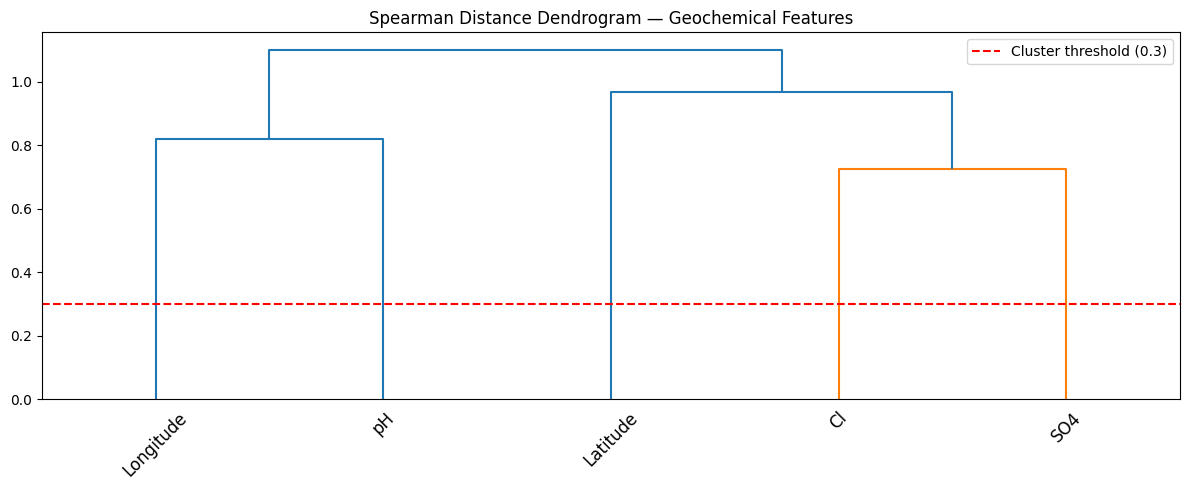

=== S4.5+N10.6 Feature clusters (Spearman distance, t=0.3) ===
  feature  cluster
Longitude        1
       pH        2
       Cl        3
      SO4        4
 Latitude        5

Redundant feature groups (consider dropping one from each):
Empty DataFrame
Columns: [feature, cluster]
Index: []


In [17]:
# S4.5 + N10.6 — Spearman correlation dendrogram for feature redundancy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster import hierarchy

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'
_feat_cols = [c for c in _df.select_dtypes(include=[np.number]).columns if c != _TARGET]
_X_feat = _df[_feat_cols].dropna(axis=1, thresh=int(0.5 * len(_df)))
_X_filled = _X_feat.fillna(_X_feat.median())

if _X_feat.shape[1] >= 2:
    _corr_result = spearmanr(_X_filled)
    _corr_mat = np.array(_corr_result.statistic if hasattr(_corr_result, 'statistic')
                         else _corr_result.correlation)
    if _corr_mat.ndim == 0:
        _corr_mat = np.array([[1.0, float(_corr_mat)], [float(_corr_mat), 1.0]])
    _dist = 1 - np.abs(_corr_mat)
    np.fill_diagonal(_dist, 0)
    _dist_condensed = _dist[np.triu_indices(_dist.shape[0], k=1)]
    _z = hierarchy.ward(_dist_condensed)
    _labels = _X_feat.columns.tolist()

    fig, ax = plt.subplots(figsize=(12, 5))
    hierarchy.dendrogram(_z, labels=_labels, ax=ax, leaf_rotation=45)
    ax.axhline(0.3, color='red', linestyle='--', label='Cluster threshold (0.3)')
    ax.set_title('Spearman Distance Dendrogram — Geochemical Features')
    ax.legend()
    plt.tight_layout(); plt.savefig('spearman_dendrogram.png', dpi=600); plt.show()

    _clusters = hierarchy.fcluster(_z, t=0.3, criterion='distance')
    _cluster_df = pd.DataFrame({'feature': _labels, 'cluster': _clusters}).sort_values('cluster')
    print("=== S4.5+N10.6 Feature clusters (Spearman distance, t=0.3) ===")
    print(_cluster_df.to_string(index=False))
    _redundant = _cluster_df[_cluster_df.groupby('cluster')['cluster'].transform('count') > 1]
    print(f"\nRedundant feature groups (consider dropping one from each):")
    print(_redundant.to_string(index=False))
else:
    print("Fewer than 2 numeric features — skipping dendrogram.")

In [18]:
# D1.10 — Theil's U (asymmetric categorical correlation)
# Confirm region/state redundancy before dropping categorical columns
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import entropy


def _theils_u(x, y):
    """Theil's U: H(x|y)/H(x). Range [0,1]. Asymmetric."""
    _xy = pd.crosstab(pd.Series(x), pd.Series(y))
    _px = _xy.sum(axis=1) / _xy.sum().sum()
    _hx = float(entropy(_px))
    if _hx == 0:
        return 1.0
    _py = _xy.sum(axis=0) / _xy.sum().sum()
    _hxy = float(sum(-(_xy[c] / _xy[c].sum() * np.log(_xy[c] / _xy[c].sum() + 1e-12) * _py[c]).sum()
                     for c in _xy.columns))
    return (_hx - _hxy) / _hx


_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)

_cat_candidates = _df.select_dtypes(include=['object', 'category']).columns.tolist()
_low_card = [c for c in _df.select_dtypes(include=[np.number]).columns
             if _df[c].nunique() <= 20 and c != 'Temperature(C)']
_cat_cols = _cat_candidates + _low_card

_rows = []
for _c1 in _cat_cols:
    for _c2 in _cat_cols:
        if _c1 == _c2:
            continue
        _u = _theils_u(_df[_c1].fillna('NA'), _df[_c2].fillna('NA'))
        _rows.append({'x': _c1, 'y': _c2, 'theils_u_x_given_y': _u})

if _rows:
    _u_df = pd.DataFrame(_rows).pivot(index='x', columns='y', values='theils_u_x_given_y')
    print("=== D1.10 Theil's U matrix ===")
    print(_u_df.round(3).to_string())
    print("\nHigh Theil's U (>0.8) → redundant pair — consider dropping one column.")
else:
    print("No categorical column pairs detected in this dataset.")

No categorical column pairs detected in this dataset.


In [19]:
# N8.5 — Environment watermark for reproducibility
try:
    import watermark
    %load_ext watermark
    %watermark -v -p numpy,pandas,scikit-learn,scipy,matplotlib,xgboost
except ImportError:
    import sys, numpy, pandas, sklearn, scipy, matplotlib
    print(f"Python {sys.version}")
    print(f"numpy={numpy.__version__}, pandas={pandas.__version__}")
    print(f"scikit-learn={sklearn.__version__}, scipy={scipy.__version__}")
    print(f"matplotlib={matplotlib.__version__}")
    try:
        import xgboost; print(f"xgboost={xgboost.__version__}")
    except ImportError:
        pass

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.11.0

numpy       : 2.4.2
pandas      : 2.2.2
scikit-learn: 1.8.0
scipy       : 1.17.1
matplotlib  : 3.10.8
xgboost     : 3.2.0

